In [7]:
dataset = 'breast_cancer'
seed = 42

In [8]:
import pandas as pd
import os
import sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))
from experiments.utils import *
pd.set_option('future.no_silent_downcasting', True)

In [9]:
def preprocess_df(df):
    df_filtered = df[['val_score'] + df.filter(like='config').columns.tolist()]
    df_filtered.columns = df_filtered.columns.str.replace('config/', '', regex=False)
    
    df_filtered = df_filtered[df_filtered['val_score'] > 0]

    constants = {col: df_filtered[col].iloc[0] for col in df_filtered if df_filtered[col].nunique() == 1}

    df_filtered = df_filtered.replace({True: 1, False: 0, 'True': 1, 'False': 0, 'TRUE': 1, 'FALSE': 0})
    
    empty_cols = df_filtered.columns[df_filtered.isna().all()]

    df_filtered.drop(columns=['input_dim', 'hidden_dims', 'threshold_dim', 'threshold_init'], inplace=True, errors='ignore')
    df_filtered.drop(columns=constants.keys(), inplace=True, errors='ignore')
    df_filtered.drop(columns=empty_cols, inplace=True, errors='ignore')
    
    df_filtered = df_filtered.sort_values(by=['val_score'], ascending=False)
    
    df_filtered.reset_index(drop=True, inplace=True)
    
    return df_filtered

In [10]:
file_path = f"{get_params_path(dataset, seed)}/hpo.csv"
df = pd.read_csv(file_path)
df = preprocess_df(df)
df.head(10)

,val_score,learning_rate,num_hidden_layers,first_hl_size,last_hl_size_wrt_first,continuous_resolution,tau_out,grad_factor
0,0.979343,0.038448,3,187,0.959991,4,5.027078,1.591933
1,0.976789,0.043176,4,216,0.998866,4,2.442365,1.575418
2,0.971550,0.060636,4,223,0.996499,6,1.463458,1.448393
3,0.971071,0.033379,4,224,0.843259,4,4.921758,1.480753
4,0.970995,0.031953,4,225,0.816275,4,2.255982,1.440074
5,0.970309,0.020329,4,212,0.830588,4,5.380850,1.558989
6,0.969499,0.043442,4,185,0.977129,4,2.706861,1.576497
7,0.968750,0.010190,5,187,0.686825,4,3.384522,1.115869
8,0.968418,0.147247,3,204,0.679106,4,5.826180,1.655341
9,0.968259,0.061100,3,179,0.998473,6,1.451881,1.414871


/home/crw1213/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


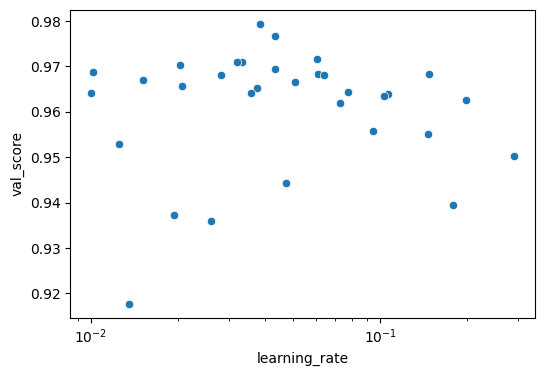

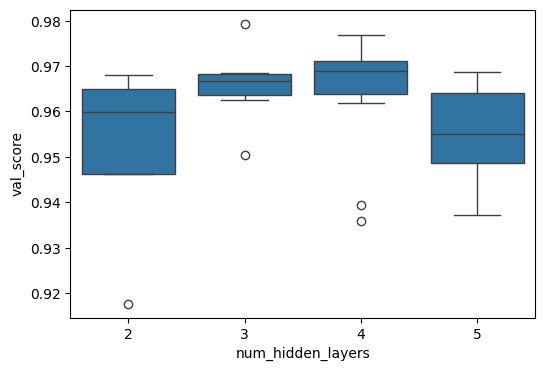

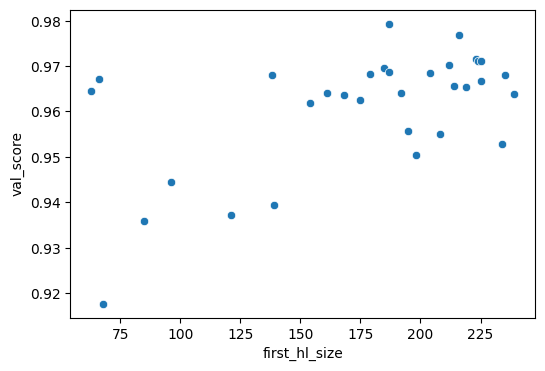

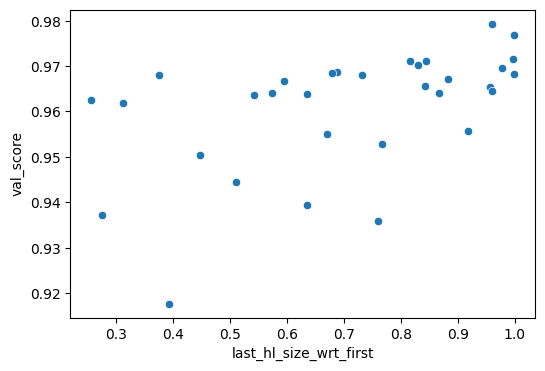

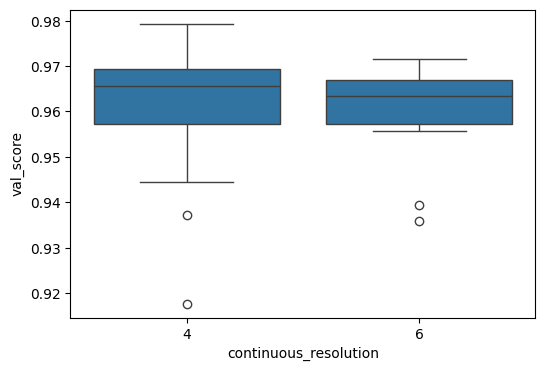

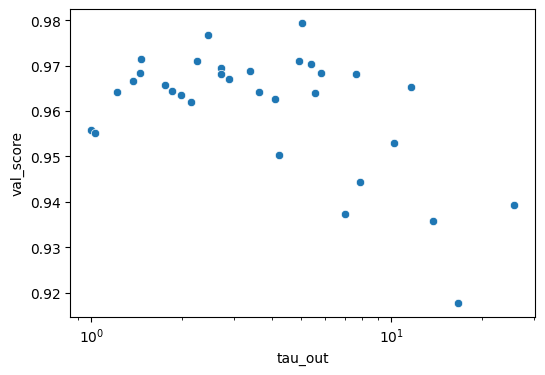

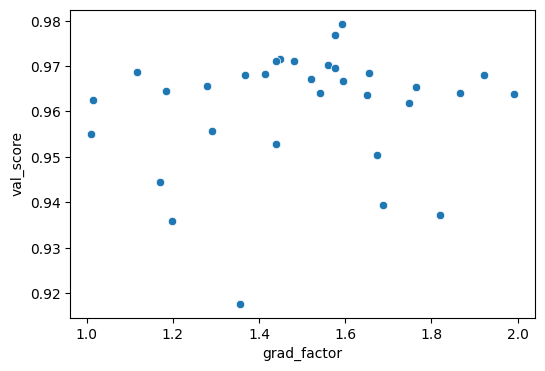

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")


cutoff = 10
categorical_cols = df.columns[df.nunique() <= cutoff].tolist()
categorical_cols = [col for col in categorical_cols if col != 'val_score']
numerical_cols = df.columns[df.nunique() > cutoff].tolist()
numerical_cols = [col for col in numerical_cols if col != 'val_score']

for col in df.columns:
    if col == 'val_score':
        continue
    plt.figure(figsize=(6, 4))
    if col in categorical_cols:
        sns.boxplot(x=df[col], y=df['val_score'])
    else:
        sns.scatterplot(x=df[col], y=df['val_score'])
        if max(df[col]) > min(df[col])*10:
            plt.xscale('log')
    plt.xlabel(col)
    plt.ylabel('val_score')
    plt.show()


In [12]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

y = df['val_score']
X = df.drop('val_score', axis=1)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)
features = numerical_cols + (list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)) if len(categorical_cols) > 0 else [])


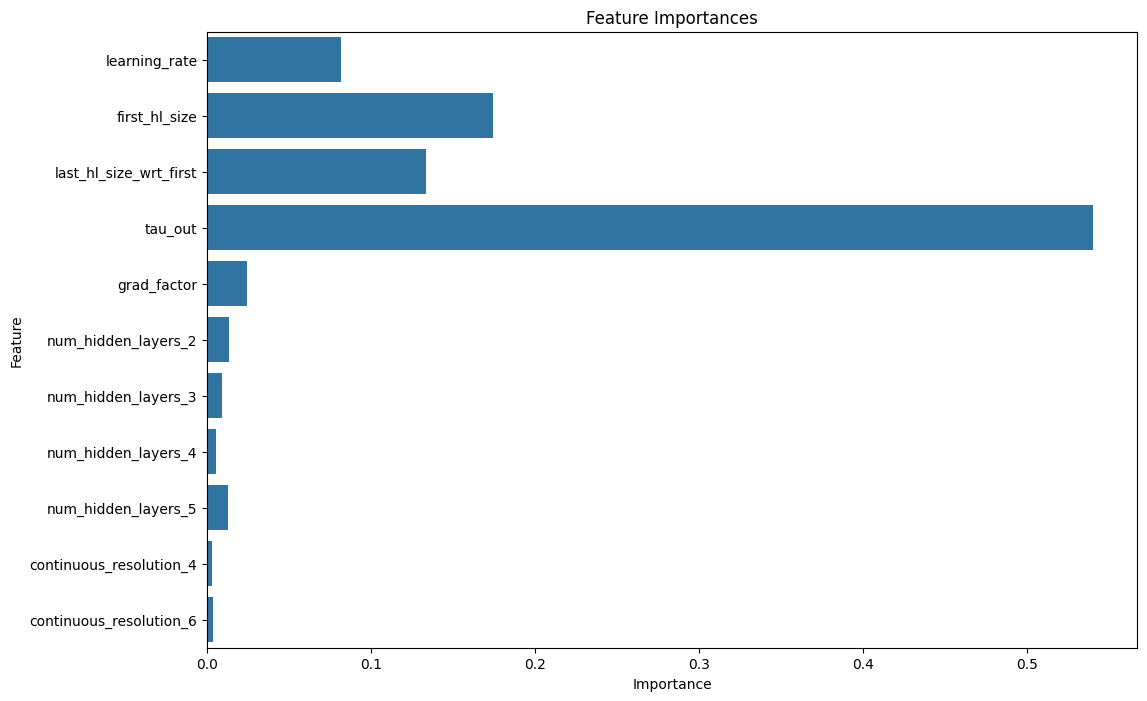

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_processed, y)

feature_importances = rf.feature_importances_

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances, y=features)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [8]:
# import statsmodels.api as sm


# X_processed_df = pd.DataFrame(X_processed, columns=features)

# X_with_constant = sm.add_constant(X_processed_df)

# model = sm.OLS(y, X_with_constant).fit()

# print(model.summary())
